# Sales Performance Analysis — Superstore (2015–2018)

**Goal:** answer three business questions for management:
1. How did overall performance evolve by year and by product sub-category?
2. Were promotions (discounts) effective and efficient?
3. How do customers behave, and is the customer base growing?

> Notebook walkthrough. The same logic is productionised in `src/` and mirrored in SQL in `sql/`.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
usd_k = FuncFormatter(lambda x, _: f"{'-' if x < 0 else ''}${abs(x)/1000:,.0f}K")

df = pd.read_csv("../data/processed/orders_clean.csv", parse_dates=["order_date", "ship_date"])
print(df.shape)
df.head(3)

(9994, 28)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,quantity,discount,profit,order_year,order_month,year_month,ship_days,margin_pct,is_loss,discount_band
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.0,41.9136,2017,11,2017-11,3,16.0,0,0%
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.0,219.5820,2017,11,2017-11,3,30.0,0,0%
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.0,6.8714,2017,6,2017-06,4,47.0,0,0%


## 1. Data overview

In [2]:
print(f"Period    : {df.order_date.min():%d %b %Y} -> {df.order_date.max():%d %b %Y}")
print(f"Orders    : {df.order_id.nunique():,}   Customers: {df.customer_id.nunique():,}   Products: {df.product_id.nunique():,}")
print(f"Sales     : ${df.sales.sum():,.0f}   Profit: ${df.profit.sum():,.0f}   Margin: {df.profit.sum()/df.sales.sum():.1%}")
df[["sales", "quantity", "discount", "profit"]].describe().round(2)

Period    : 03 Jan 2015 -> 30 Dec 2018
Orders    : 5,009   Customers: 793   Products: 1,862
Sales     : $2,297,201   Profit: $286,397   Margin: 12.5%


,sales,quantity,discount,profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


**Cleaning notes** (see `src/01_clean.py` and `reports/data_quality.md`): the raw export had 806 extra rows from appended *People/Returns* worksheets (dropped) and 11 rows with a missing ZIP code (Burlington, VT → 05401). All validation checks pass.

## 2. Overall performance by year

In [3]:
y = df.groupby("order_year").agg(sales=("sales","sum"), profit=("profit","sum"),
                                 orders=("order_id","nunique"), customers=("customer_id","nunique"))
y["margin_%"] = y.profit / y.sales * 100
y["aov"] = y.sales / y.orders
y["sales_yoy_%"] = y.sales.pct_change() * 100
y.round(1)

,sales,profit,orders,customers,margin_%,aov,sales_yoy_%
order_year,,,,,,,
2015,484247.5,49544.0,969,595,10.2,499.7,NaN
2016,470532.5,61618.6,1038,573,13.1,453.3,-2.8
2017,609205.6,81795.2,1315,638,13.4,463.3,29.5
2018,733215.3,93439.3,1687,693,12.7,434.6,20.4


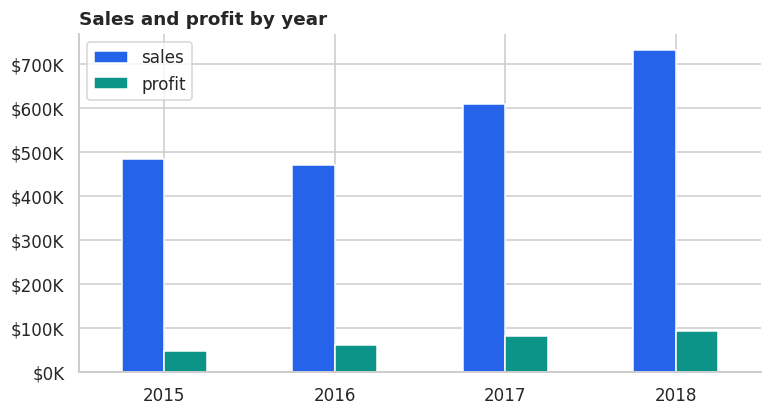

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
y[["sales", "profit"]].plot.bar(ax=ax, rot=0, color=["#2563eb", "#0d9488"])
ax.yaxis.set_major_formatter(usd_k); ax.set_xlabel(""); ax.set_title("Sales and profit by year", loc="left", fontweight="bold")
plt.show()

**Reading:** sales dipped 2.8% in 2016 then grew +29% (2017) and +20% (2018). Margin improved from 10.2% to ~13%, but slipped in 2018 (12.7%) — profit grew slower (+14%) than sales (+20%). Average order value also fell from \$500 to \$435 while order count rose 74%: growth is coming from *more, smaller orders*.

## 3. Sub-category performance

In [5]:
sc = df.groupby("sub_category").agg(sales=("sales","sum"), profit=("profit","sum"))
sc["margin_%"] = sc.profit / sc.sales * 100
yr = df.pivot_table(index="sub_category", columns="order_year", values="sales", aggfunc="sum")
sc["cagr_%"] = ((yr[2018] / yr[2015]) ** (1/3) - 1) * 100
sc.sort_values("profit").round(1)

,sales,profit,margin_%,cagr_%
sub_category,,,,
Tables,206965.5,-17725.5,-8.6,9.7
Bookcases,114880.0,-3472.6,-3.0,14.4
Supplies,46673.5,-1189.1,-2.5,3.7
Fasteners,3024.3,949.5,31.4,9.0
Machines,189238.6,3384.8,1.8,-11.1
Labels,12486.3,5546.3,44.4,10.8
Art,27118.8,6527.8,24.1,13.5
Envelopes,16476.4,6964.2,42.3,-4.3
Furnishings,91705.2,13059.1,14.2,27.9


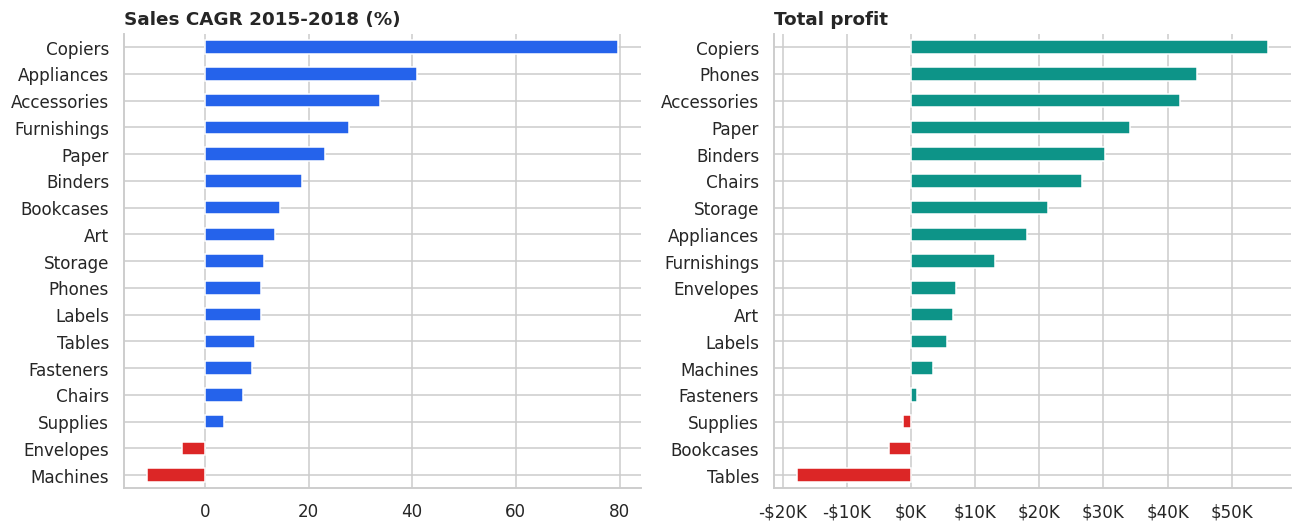

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc["cagr_%"].sort_values().plot.barh(ax=axes[0], color=["#dc2626" if v < 0 else "#2563eb" for v in sc["cagr_%"].sort_values()])
axes[0].set_title("Sales CAGR 2015-2018 (%)", loc="left", fontweight="bold"); axes[0].set_ylabel("")
sc.profit.sort_values().plot.barh(ax=axes[1], color=["#dc2626" if v < 0 else "#0d9488" for v in sc.profit.sort_values()])
axes[1].xaxis.set_major_formatter(usd_k); axes[1].set_title("Total profit", loc="left", fontweight="bold"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

**Reading:**
- **Tables** is a \$207K-revenue line that *loses* \$17.7K (margin −8.6%); **Bookcases** and **Supplies** also lose money.
- **Copiers** is the star: sales CAGR +80% with a 37% margin. **Machines** is shrinking (−11% CAGR) and turned unprofitable in 2018.
- **Paper, Labels, Envelopes, Fasteners, Art** have 24–44% margins but tiny revenue — upsell/bundle candidates.

## 4. Promotion effectiveness (discount as proxy)

Superstore has no promotion table, so the `discount` field is used as a proxy for promotional intensity.

In [7]:
bands = ["0%", "1-10%", "11-20%", "21-30%", "31-50%", ">50%"]
b = df.groupby("discount_band").agg(lines=("sales","size"), sales=("sales","sum"), profit=("profit","sum"),
                                    avg_qty=("quantity","mean"), loss_line_share=("is_loss","mean")).reindex(bands)
b["margin_%"] = b.profit / b.sales * 100
b["sales_share_%"] = b.sales / b.sales.sum() * 100
b["loss_line_share"] = b.loss_line_share * 100
b.round(1)

,lines,sales,profit,avg_qty,loss_line_share,margin_%,sales_share_%
discount_band,,,,,,,
0%,4798,1087908.5,320987.6,3.8,0.0,29.5,47.4
1-10%,94,54369.4,9029.2,4.0,4.3,16.6,2.4
11-20%,3709,792152.9,91756.3,3.7,14.0,11.6,34.5
21-30%,227,103226.7,-10369.3,3.7,91.6,-10.0,4.5
31-50%,310,195314.8,-48447.7,3.8,91.6,-24.8,8.5
>50%,856,64228.7,-76559.1,3.9,100.0,-119.2,2.8


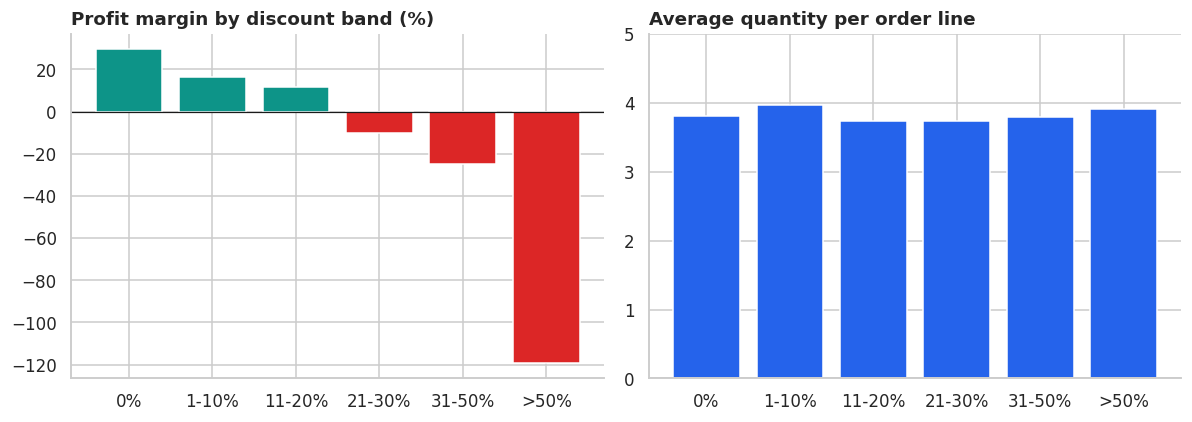

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(b.index, b["margin_%"], color=["#0d9488" if v >= 0 else "#dc2626" for v in b["margin_%"]])
axes[0].axhline(0, color="k", lw=.8); axes[0].set_title("Profit margin by discount band (%)", loc="left", fontweight="bold")
axes[1].bar(b.index, b.avg_qty, color="#2563eb"); axes[1].set_ylim(0, 5)
axes[1].set_title("Average quantity per order line", loc="left", fontweight="bold")
plt.tight_layout(); plt.show()

In [9]:
hi, lo = df[df.discount > 0.20], df[df.discount <= 0.20]
print(f"Lines with discount > 20%      : {len(hi)/len(df):.1%} of lines, {hi.sales.sum()/df.sales.sum():.1%} of sales")
print(f"Profit from lines <= 20% disc. : ${lo.profit.sum():,.0f}")
print(f"Profit from lines  > 20% disc. : ${hi.profit.sum():,.0f}  -> erases {-hi.profit.sum()/lo.profit.sum():.0%} of the profit earned elsewhere")

Lines with discount > 20%      : 13.9% of lines, 15.8% of sales
Profit from lines <= 20% disc. : $421,773
Profit from lines  > 20% disc. : $-135,376  -> erases 32% of the profit earned elsewhere


**Reading:** margin is 29.5% with no discount, 11.6% at 11–20%, and negative above 20% (−10% → −25% → −119%). Average quantity per line stays ~3.7–3.9 in *every* band, so deeper discounts are **not associated with larger baskets** — they just give margin away. Lines discounted >20% are 14% of volume but destroy **\$135K = 32%** of the profit earned at ≤20% discount. (Association, not proof of causation — discounts may be targeted at already-weak products.)

### Is the weak Central region a demand problem or a discount problem?

In [10]:
rd = df.groupby("region").apply(lambda x: pd.Series({
    "margin_%": x.profit.sum() / x.sales.sum() * 100,
    "avg_discount_%": x.discount.mean() * 100,
    "lines_>20%_disc_share_%": (x.discount > .2).mean() * 100,
    "profit_lost_>20%_disc": x.loc[x.discount > .2, "profit"].sum(),
    "margin_if_<=20%_only_%": x.loc[x.discount <= .2, "profit"].sum() / x.loc[x.discount <= .2, "sales"].sum() * 100,
}), include_groups=False)
rd.round(1)

,margin_%,avg_discount_%,lines_>20%_disc_share_%,profit_lost_>20%_disc,margin_if_<=20%_only_%
region,,,,,
Central,7.9,24.0,27.7,-52392.3,24.8
East,13.5,14.5,16.2,-42088.6,25.1
South,11.9,14.7,10.6,-24880.5,22.3
West,14.9,10.9,3.7,-16014.7,17.6


**Reading:** Central has the lowest margin (7.9%) *and* the heaviest discounting (24% average; 28% of lines above 20%). Excluding >20% discount lines, Central's margin (24.8%) is on par with East (25.1%) — the gap is explained by discount policy, not by demand.

## 5. Customer behaviour & growth

In [11]:
first = df.groupby("customer_id").order_year.min().rename("first_year")
d2 = df.join(first, on="customer_id")
nv = d2.groupby("order_year").apply(lambda g: pd.Series({
    "new": g.loc[g.first_year == g.name, "customer_id"].nunique(),
    "returning": g.loc[g.first_year < g.name, "customer_id"].nunique()}), include_groups=False)
active = df.groupby("order_year").customer_id.apply(set)
nv["retention_next_yr_%"] = [len(active[yr] & active[yr+1]) / len(active[yr]) * 100 if yr < 2018 else np.nan for yr in nv.index]
nv.round(1)

,new,returning,retention_next_yr_%
order_year,,,
2015,595,0,73.4
2016,136,437,78.9
2017,51,587,87.5
2018,11,682,NaN


In [12]:
opc = df.groupby("customer_id").order_id.nunique()
cs = df.groupby("customer_id").sales.sum().sort_values(ascending=False)
print(f"Customers with 2+ orders: {(opc >= 2).mean():.1%}   |   median orders per customer: {opc.median():.0f}")
print(f"Top 20% of customers generate {cs.head(int(len(cs)*.2)).sum()/cs.sum():.1%} of sales")

Customers with 2+ orders: 98.5%   |   median orders per customer: 6
Top 20% of customers generate 48.0% of sales


**Reading:** 2015 is the first year in the data, so its 595 customers are all "new" by construction. After that, acquisition collapses: **136 → 51 → 11** new customers a year, while retention improves (73% → 79% → 87%). Growth since 2016 is therefore almost entirely **more spend from existing customers**; the base of ~790 customers looks saturated. 98% of customers order at least twice, and the top 20% bring 48% of sales.

### RFM segmentation

In [13]:
snap = df.order_date.max() + pd.Timedelta(days=1)
rfm = df.groupby("customer_id").agg(recency=("order_date", lambda s: (snap - s.max()).days),
                                    frequency=("order_id", "nunique"), monetary=("sales", "sum"))
rfm["R"] = pd.qcut(rfm.recency.rank(method="first", ascending=False), 4, labels=[1,2,3,4]).astype(int)
rfm["F"] = pd.qcut(rfm.frequency.rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["M"] = pd.qcut(rfm.monetary.rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["score"] = rfm[["R","F","M"]].sum(axis=1)
rfm["segment"] = pd.cut(rfm.score, [2, 3, 5, 7, 9, 12], labels=["Lost","At Risk","Potential","Loyal","Champions"])
seg = rfm.groupby("segment", observed=True).agg(customers=("monetary","size"), sales=("monetary","sum"), avg_recency_days=("recency","mean"))
seg["customer_share_%"] = seg.customers / seg.customers.sum() * 100
seg["sales_share_%"] = seg.sales / seg.sales.sum() * 100
seg.iloc[::-1].round(1)

,customers,sales,avg_recency_days,customer_share_%,sales_share_%
segment,,,,,
Champions,191,915262.8,36.6,24.1,39.8
Loyal,221,816358.8,91.0,27.9,35.5
Potential,183,377076.1,151.9,23.1,16.4
At Risk,143,160989.0,246.9,18.0,7.0
Lost,55,27514.1,490.4,6.9,1.2


**Reading:** *Champions* are 24% of customers and 40% of sales. *At Risk* + *Lost* are ~25% of customers but only ~8% of sales — a win-back campaign should target At Risk (avg. ~250 days since last order) rather than Lost.

## 6. Recommendations

1. **Cap discounts at 20%** (hard approval above that). Deep discounts show no volume benefit and wipe out ~32% of profit earned elsewhere.
2. **Fix or re-price Tables, Bookcases, Supplies** — more than half of Tables lines carry >20% discounts.
3. **Review Central region discount policy** — its margin gap vs. East/West is a pricing-discipline issue.
4. **Double down on Copiers, Accessories, Appliances** (high growth, healthy margin); bundle high-margin Paper/Labels/Envelopes into orders.
5. **Restart customer acquisition** — new customers fell to 11 in 2018; the business depends on a saturated base. Run win-back for *At Risk* and a loyalty tier for *Champions*.

**Limitations:** discount is a proxy for promotions (no campaign data); 2015 "new customers" is left-censored; 2018 retention can't be measured; results describe association, not causation.